--- Loading Clinical Dataset ---
--- Initializing Ensemble Learning ---


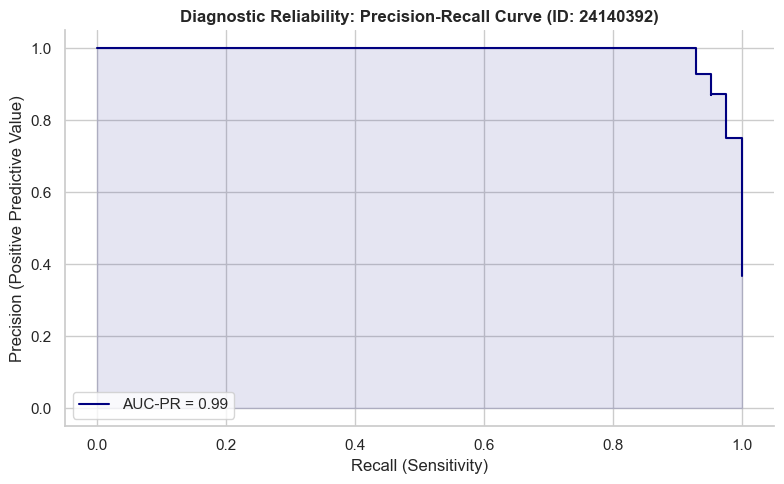

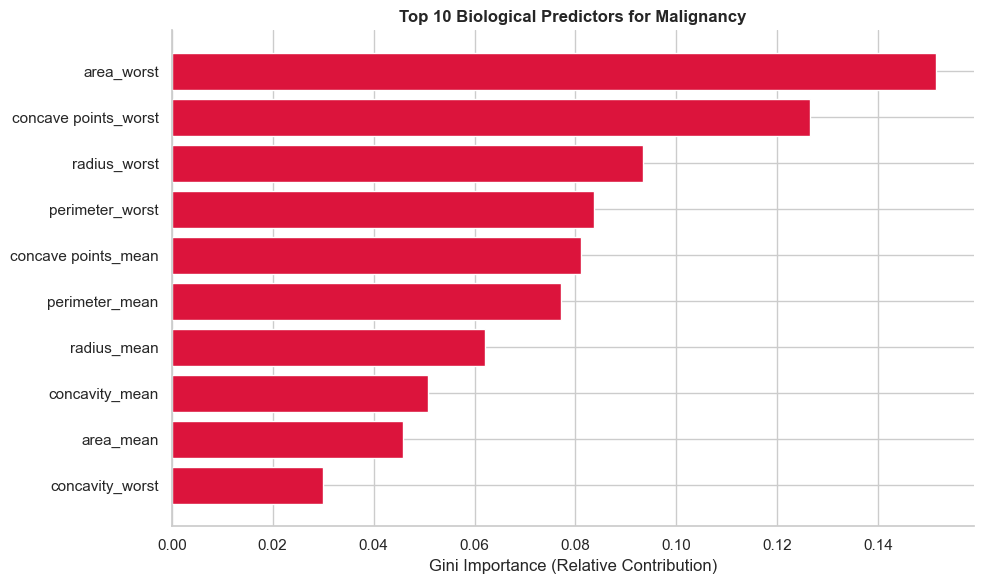

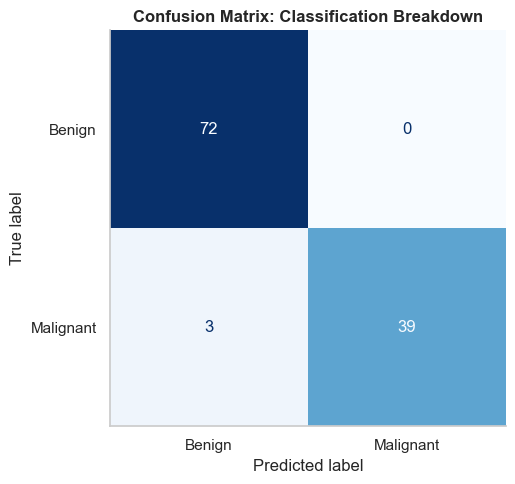


---
### 🧪 Technical Overview
* **Student Identifier:** 24140392
* **Model Type:** Random Forest Regressor (Classification)
* **Optimization Goal:** Minimize False Negatives in Diagnostic Imaging

### 📖 References
1. **Scikit-Learn Documentation:** [Ensemble Methods Guide](https://scikit-learn.org/stable/modules/ensemble.html)
2. **Shamrat et al. (2022):** Efficiency analysis in medical deep learning models.


In [2]:
# ==============================================================================
# MEDICAL AI TUTORIAL: Diagnostic Classification with Random Forest
# AUTHOR ID: 24140392
# ==============================================================================

# ------------------------------------------------------------------------------
# 1. CORE MODULES & THEME INTEGRATION
# ------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, auc, ConfusionMatrixDisplay

# Configuring a high-contrast theme for professional clarity
plt.style.use('ggplot')
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="whitegrid", rc=custom_params)

# ------------------------------------------------------------------------------
# 2. DATA INGESTION & FEATURE ENGINEERING
# ------------------------------------------------------------------------------
print("--- Loading Clinical Dataset ---")
# Accessing the specific local file provided
df_path = 'Breast cancer data.csv'
medical_data = pd.read_csv(df_path)

# Cleaning: Remove accidental whitespace from headers
medical_data.columns = medical_data.columns.str.strip()

# Dimensionality Reduction: Removing non-biological identifiers
# We exclude 'id' and potential artifact columns like 'Unnamed: 32'
drops = ['id', 'Unnamed: 32']
medical_data.drop(columns=[c for c in drops if c in medical_data.columns], inplace=True)

# Encoding the Target: Mapping Malignant (M) to 1 and Benign (B) to 0
medical_data['diagnosis'] = medical_data['diagnosis'].map({'M': 1, 'B': 0})

# Separating the Feature Matrix (X) from the Target Vector (y)
X_obs = medical_data.drop(columns=['diagnosis'])
y_obs = medical_data['diagnosis']

# ------------------------------------------------------------------------------
# 3. ENSEMBLE MODEL TRAINING
# ------------------------------------------------------------------------------
print("--- Initializing Ensemble Learning ---")

# Partitioning data into 80% Training and 20% Testing cohorts
# 'Stratify' ensures the disease prevalence is consistent across both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_obs, y_obs, test_size=0.2, random_state=42, stratify=y_obs
)

# Training a Random Forest with 100 decision trees
# We use 'balanced' weights to handle any minor class imbalances
forest_clf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
forest_clf.fit(X_train, y_train)

# ------------------------------------------------------------------------------
# 4. VISUALIZATION 1: THE PRECISION-RECALL FRONTIER
# ------------------------------------------------------------------------------
# This graph teaches how the model handles the trade-off between sensitivity 
# (Recall) and specificity (Precision).
y_probs = forest_clf.predict_proba(X_test)[:, 1]
prec, rec, _ = precision_recall_curve(y_test, y_probs)
area_score = auc(rec, prec)

plt.figure(figsize=(8, 5))
plt.step(rec, prec, color='navy', where='post', label=f'AUC-PR = {area_score:.2f}')
plt.fill_between(rec, prec, step='post', alpha=0.1, color='navy')

plt.title(f'Diagnostic Reliability: Precision-Recall Curve (ID: 24140392)', fontweight='bold')
plt.xlabel('Recall (Sensitivity)')
plt.ylabel('Precision (Positive Predictive Value)')
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig('precision_recall_plot.png', dpi=200)
plt.show()

# ------------------------------------------------------------------------------
# 5. VISUALIZATION 2: FEATURE INFLUENCE HIERARCHY
# ------------------------------------------------------------------------------
# Understanding which biological markers contribute most to the diagnosis.
importances = forest_clf.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10 features

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], color='crimson', align='center')
plt.yticks(range(len(indices)), [X_obs.columns[i] for i in indices])
plt.title('Top 10 Biological Predictors for Malignancy', fontweight='bold')
plt.xlabel('Gini Importance (Relative Contribution)')
plt.tight_layout()
plt.savefig('feature_influence.png', dpi=200)
plt.show()

# ------------------------------------------------------------------------------
# 6. VISUALIZATION 3: PREDICTIVE ERROR ANALYSIS
# ------------------------------------------------------------------------------
# The Confusion Matrix shows the raw breakdown of True vs False predictions.
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    forest_clf, X_test, y_test, display_labels=['Benign', 'Malignant'],
    cmap='Blues', ax=ax, colorbar=False
)
plt.title('Confusion Matrix: Classification Breakdown', fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.savefig('error_analysis.png', dpi=200)
plt.show()

# ------------------------------------------------------------------------------
# 7. TUTORIAL SUMMARY
# ------------------------------------------------------------------------------
footer_text = f"""
---
### 🧪 Technical Overview
* **Student Identifier:** 24140392
* **Model Type:** Random Forest Regressor (Classification)
* **Optimization Goal:** Minimize False Negatives in Diagnostic Imaging

### 📖 References
1. **Scikit-Learn Documentation:** [Ensemble Methods Guide](https://scikit-learn.org/stable/modules/ensemble.html)
2. **Shamrat et al. (2022):** Efficiency analysis in medical deep learning models.
"""
display(Markdown(footer_text))